In [81]:
import math

import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt

## Реализация VE-SDE

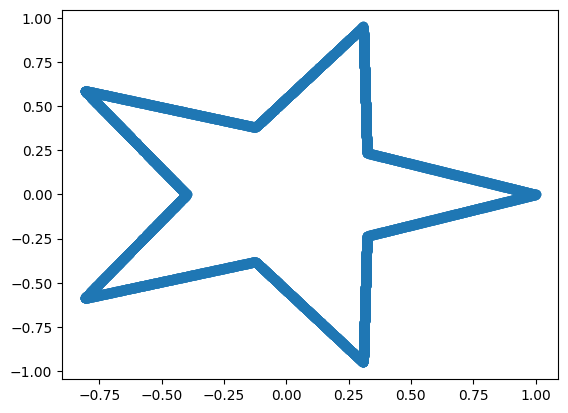

In [82]:
def generate_star(n_spikes=5, inner_radius=0.4, outer_radius=1.0, n_samples=1000, center=(0, 0)):
    points = []
    angle_step = np.pi / n_spikes

    vertices = []
    for i in range(2 * n_spikes):
        angle = i * angle_step
        radius = outer_radius if i % 2 == 0 else inner_radius

        x = radius * np.cos(angle) + center[0]
        y = radius * np.sin(angle) + center[1]
        vertices.append([x, y])
    vertices.append(vertices[0])

    vertices = np.array(vertices)
    sampled_points = []

    for i in range(len(vertices) - 1):
        start_point = vertices[i]
        end_point = vertices[i + 1]

        for t in np.linspace(0, 1, n_samples // (len(vertices) - 1)):
            point = (1 - t) * start_point + t * end_point
            sampled_points.append(point)

    return np.array(sampled_points)


s = generate_star(n_samples=5000)

plt.scatter(s[:, 0], s[:, 1])
plt.show()

In [83]:
class VEConfig:
    sigma_min = 0.01
    sigma_max = 4.0

    lr = 1e-3
    epochs = 2000
    batch_size = 512
    hidden_dim = 256
    num_timesteps = 1000
    data_samples = 5000

In [84]:
class ScoreModel(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.config = config

        self.time_embed = nn.Sequential(
            nn.Linear(1, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.hidden_dim)
        )

        self.net = nn.Sequential(
            nn.Linear(2 + config.hidden_dim, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, 2)
        )

    def forward(self, x, t):
        t_embed = self.time_embed(t)
        x_input = torch.cat([x, t_embed], dim=1)

        return self.net(x_input)

In [85]:
def sigma_t(t, config):
    return config.sigma_min * (config.sigma_max / config.sigma_min) ** t

def g_t(t, config):
    sigma = sigma_t(t, config)
    c = math.sqrt(2.0 * math.log(config.sigma_max / config.sigma_min))

    return sigma * c

In [86]:
class VETrainer():
    def __init__(self, config):
        self.config = config
        self.device = torch.device('cuda') if torch.cuda.is_available() else 'cpu'

        star = generate_star(n_samples=config.data_samples)
        self.data = torch.tensor(star, dtype=torch.float32)

        self.dataset = TensorDataset(self.data)
        self.dataloader = DataLoader(self.dataset, batch_size=config.batch_size, shuffle=True)

        self.model = ScoreModel(config).to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.lr)

    def train_epoch(self):
        self.model.train()
        total_loss = 0.0

        for (batch, ) in self.dataloader:
            batch = batch.to(self.device)

            t = torch.rand(batch.shape[0], 1, device=self.device)
            sigma = sigma_t(t, self.config)

            z = torch.randn_like(batch)
            x_t = batch + sigma * z

            pred_z = self.model(x_t, t)
            # loss = ((sigma * pred_z + z) ** 2).sum(dim=1).mean()
            loss = F.mse_loss(pred_z, z)

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

            total_loss += loss.item() * batch.shape[0]

        return total_loss / len(self.data)

    def run(self):
        for n in range(self.config.epochs):
            loss = self.train_epoch()
            if n % 100 == 0:
                print(f'Loss: {loss}')

In [ ]:
config = VEConfig()
trainer = VETrainer(config)

In [ ]:
trainer.run()

Loss: 0.9108512625694275
Loss: 0.6330559053421021
Loss: 0.6169260847091674
Loss: 0.6204991786956787
Loss: 0.5963214811325073
Loss: 0.5705348756790161
Loss: 0.5916126774787903
Loss: 0.5770641940116882
Loss: 0.5767837842941285
Loss: 0.5580783971786499
Loss: 0.5555065602302551
Loss: 0.5613152348518372
Loss: 0.5658447613716125
Loss: 0.5670082681655884
Loss: 0.5507789523124694
Loss: 0.5531312689781189
Loss: 0.545524628162384
Loss: 0.5387008813858032
Loss: 0.5435387391090393
Loss: 0.5397721557617188


In [87]:
def sample(model, config, num_samples=1000):
    device = torch.device('cuda') if torch.cuda.is_available() else 'cpu'
    model.eval()

    with torch.no_grad():
        x = torch.randn(num_samples, 2, device=device) * config.sigma_max

        dt = 1.0 / config.num_timesteps

        for i in range(config.num_timesteps):
            t = 1.0 - i * dt
            t = max(t, 1e-6)
            t_tensor = torch.full((num_samples, 1), t, device=device)

            sigma = sigma_t(t_tensor, config)
            gt = g_t(t_tensor, config)

            pred = model(x, t_tensor)
            score = -pred / sigma

            drift = (gt ** 2) * score * dt
            diffusion = gt * torch.randn_like(x) * math.sqrt(dt)

            x = x + drift + diffusion

        return x.cpu().numpy()

In [ ]:
samples = sample(trainer.model, trainer.config, 1000)

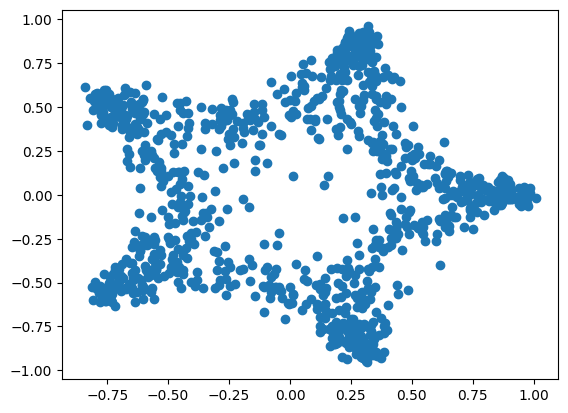

In [ ]:
plt.scatter(samples[:, 0], samples[:, 1])
plt.show()

## Реализация VP-SDE

#### Конфиг

In [100]:
class VPConfig:
    beta_min = 0.1
    beta_max = 20.0

    schedule_type = 'linear'

    lr = 5e-4
    epochs = 2000
    batch_size = 512
    hidden_dim = 256
    data_samples = 10000
    num_timesteps = 1000

    weighting_type = 'none'

#### Функции расписаний

In [119]:
def beta_linear(t, config):
    return config.beta_min + t * (config.beta_max - config.beta_min)

def beta_cosine(t, config):
    s = 0.008
    t_i = torch.clamp(t, 0.0, 1.0)

    f_t = torch.cos((t_i + s) / (1 + s) * math.pi / 2) ** 2
    f_0 = math.cos(s / (1 + s) * math.pi / 2) ** 2
    alpha_bar = f_t / f_0

    beta = (math.pi / (1 + s)) * torch.tan((t_i + s) / (1 + s) * math.pi / 2)
    beta = torch.clamp(beta, min=0.01, max=20.0)
    return beta

def beta_integral(t, config):
    match config.schedule_type:
      case 'linear':
        return config.beta_min * t + 0.5 * (config.beta_max - config.beta_min) * t**2

      case 'cosine':
        s = 0.008
        t_adj = torch.clamp(t, 0.0, 1.0)
        f_t = torch.cos((t_adj + s) / (1 + s) * math.pi / 2) ** 2
        f_0 = math.cos(s / (1 + s) * math.pi / 2) ** 2
        alpha_bar = f_t / f_0
        return -torch.log(alpha_bar.clamp(min=1e-5))


def beta_t_func(config):
  match config.schedule_type:
    case 'cosine':
      return beta_cosine

    case 'linear':
      return beta_linear

#### Взвешенный лосс

In [102]:
def l_weights(t, config):
    match config.weighting_type:
      case 'none':
        weights = torch.ones_like(t)
      case 'linear':
        weights = t + 1e-7
      case 'quadratic':
        weights = t**2 + 1e-7
    return weights

#### Функции для VP-SDE

In [103]:
def beta_t(t, config):
  beta_func = beta_t_func(config)
  return beta_func(t, config)

def l_mean(t, config):
  beta_ing = beta_t(t, config)
  return -0.5 * beta_ing


def prob_schedule_vp(x, t, config):
  beta_int = beta_integral(t, config)
  alpha_bar = torch.exp(-beta_int)

  mean = torch.sqrt(alpha_bar) * x
  sigma = torch.sqrt(1 - alpha_bar + 1e-7)

  return mean, sigma

In [104]:
class VPTrainer():
    def __init__(self, config):
        self.config = config
        self.device = torch.device('cuda') if torch.cuda.is_available() else 'cpu'

        star = generate_star(n_samples=config.data_samples)
        self.data = torch.tensor(star, dtype=torch.float32)

        self.dataset = TensorDataset(self.data)
        self.dataloader = DataLoader(self.dataset, batch_size=config.batch_size, shuffle=True)

        self.model = ScoreModel(config).to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.lr)

        self.loss_history = []

    def train_epoch(self):
        self.model.train()
        total_loss = 0.0

        for (batch,) in self.dataloader:
            batch = batch.to(self.device)

            t = torch.rand(batch.shape[0], 1, device=self.device)

            alpha_bar = torch.exp(-beta_integral(t, self.config))
            sigma = torch.sqrt(1 - alpha_bar)
            sigma = torch.clamp(sigma, min=1e-7)

            z = torch.randn_like(batch)
            x_t = torch.sqrt(alpha_bar) * batch + sigma * z

            pred_noise = self.model(x_t, t)

            loss = F.mse_loss(pred_noise, z, reduction='none').mean(dim=1, keepdim=True)

            weights = l_weights(t, self.config)

            loss = (weights * loss).mean()

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

            total_loss += loss.mean().item() * batch.shape[0]

        return total_loss / len(self.data)

    def run(self):
        for n in range(self.config.epochs):
            loss = self.train_epoch()
            self.loss_history.append(loss)
            if n % 100 == 0:
                print(f'    Epoch: {n}, loss: {loss}')

1. Реализация VP-SDE

In [105]:
my_config = VPConfig()
my_trainer = VPTrainer(my_config)

In [106]:
my_trainer.run()

    Epoch: 0, loss: 0.86260738697052
    Epoch: 100, loss: 0.18083899030685424
    Epoch: 200, loss: 0.16608691506385803
    Epoch: 300, loss: 0.16524565794467927
    Epoch: 400, loss: 0.16938470766544342
    Epoch: 500, loss: 0.15330159842967986
    Epoch: 600, loss: 0.15790859587192535
    Epoch: 700, loss: 0.1626931508541107
    Epoch: 800, loss: 0.16167048163414002
    Epoch: 900, loss: 0.1632978673696518
    Epoch: 1000, loss: 0.1566639844417572
    Epoch: 1100, loss: 0.15813069517612457
    Epoch: 1200, loss: 0.15135988767147066
    Epoch: 1300, loss: 0.154363764834404
    Epoch: 1400, loss: 0.15455188024044036
    Epoch: 1500, loss: 0.15291648502349853
    Epoch: 1600, loss: 0.15141423254013062
    Epoch: 1700, loss: 0.15286904420852662
    Epoch: 1800, loss: 0.15696371896266936
    Epoch: 1900, loss: 0.15177030560970306


In [107]:
def VPsample(model, config, num_samples=1000):
    device = torch.device('cuda') if torch.cuda.is_available() else 'cpu'
    model.eval()

    with torch.no_grad():
        x = torch.randn(num_samples, 2, device=device)

        dt = 1.0 / config.num_timesteps

        for i in range(config.num_timesteps):
            t = 1.0 - i * dt
            t = max(t, 1e-6)
            t_tensor = torch.full((num_samples, 1), t, device=device)

            beta = beta_t(t_tensor, config)
            pred_noise = model(x, t_tensor)

            mean, sigma = prob_schedule_vp(x, t_tensor, config)
            sigma = torch.clamp(sigma, min=1e-7)

            score = -pred_noise / sigma

            drift = -0.5 * beta * (x + 2 * score)
            diffusion = torch.sqrt(beta) * torch.randn_like(x)

            x = x - drift * dt + diffusion * np.sqrt(dt)

        return x.cpu().numpy()

In [108]:
samples = VPsample(my_trainer.model, my_trainer.config, 1000)

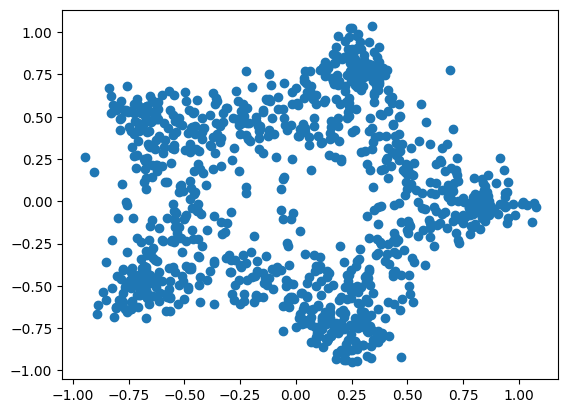

In [109]:
plt.scatter(samples[:, 0], samples[:, 1])
plt.show()

2. Графики перевзвешивания лосса от времени

In [110]:
weighting_methods = ['none', 'linear', 'quadratic'] #'snr']
results = {}

reference_star = generate_star(n_samples=10000)

for weighting in weighting_methods:
  print(f" ----> Тренируем с {weighting} весами")

  t_config = VPConfig()
  t_config.weighting_type = weighting
  t_config.epochs = 2000

  t_trainer = VPTrainer(t_config)
  t_trainer.run()
  samples = VPsample(t_trainer.model, t_config, num_samples=5000)

  results[weighting] = {
      'samples': samples,
      'loss_history': t_trainer.loss_history,
      'config': t_config
  }
  print('\n')


 ----> Тренируем с none весами
    Epoch: 0, loss: 0.8594847989082336
    Epoch: 100, loss: 0.18127535345554352
    Epoch: 200, loss: 0.16616498856544495
    Epoch: 300, loss: 0.16135454313755035
    Epoch: 400, loss: 0.16866143164634706
    Epoch: 500, loss: 0.15991563618183136
    Epoch: 600, loss: 0.1610165937900543
    Epoch: 700, loss: 0.16360686266422272
    Epoch: 800, loss: 0.15847217721939086
    Epoch: 900, loss: 0.16065758519172668
    Epoch: 1000, loss: 0.15757931506633757
    Epoch: 1100, loss: 0.15755698249340058
    Epoch: 1200, loss: 0.1525705109357834
    Epoch: 1300, loss: 0.16075439763069152
    Epoch: 1400, loss: 0.15451336064338683
    Epoch: 1500, loss: 0.1496741081237793
    Epoch: 1600, loss: 0.14666441860198975
    Epoch: 1700, loss: 0.15550935256481171
    Epoch: 1800, loss: 0.15921315941810607
    Epoch: 1900, loss: 0.14857345762252808


 ----> Тренируем с linear весами
    Epoch: 0, loss: 0.41007460498809817
    Epoch: 100, loss: 0.022267245662212373
    Epo

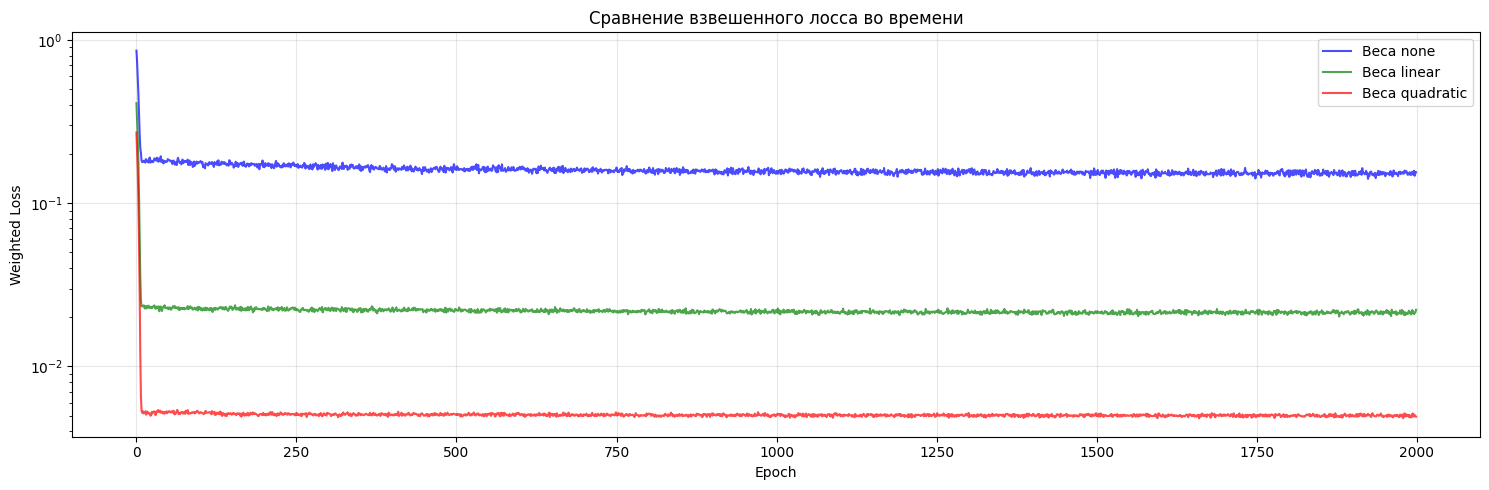

In [111]:
colors = ['blue', 'green', 'red']

fig, ax = plt.subplots(figsize=(15, 5))

for i, method in enumerate(weighting_methods):
    ax.plot(results[method]['loss_history'],
            label=f"Веса {method}",
            color=colors[i],
            alpha=0.7)

ax.set_xlabel('Epoch', fontsize=10)
ax.set_ylabel('Weighted Loss', fontsize=10)
ax.set_title('Сравнение взвешенного лосса во времени',)
ax.legend()

ax.grid(True, alpha=0.3)
ax.set_yscale('log')

plt.tight_layout()
plt.show()

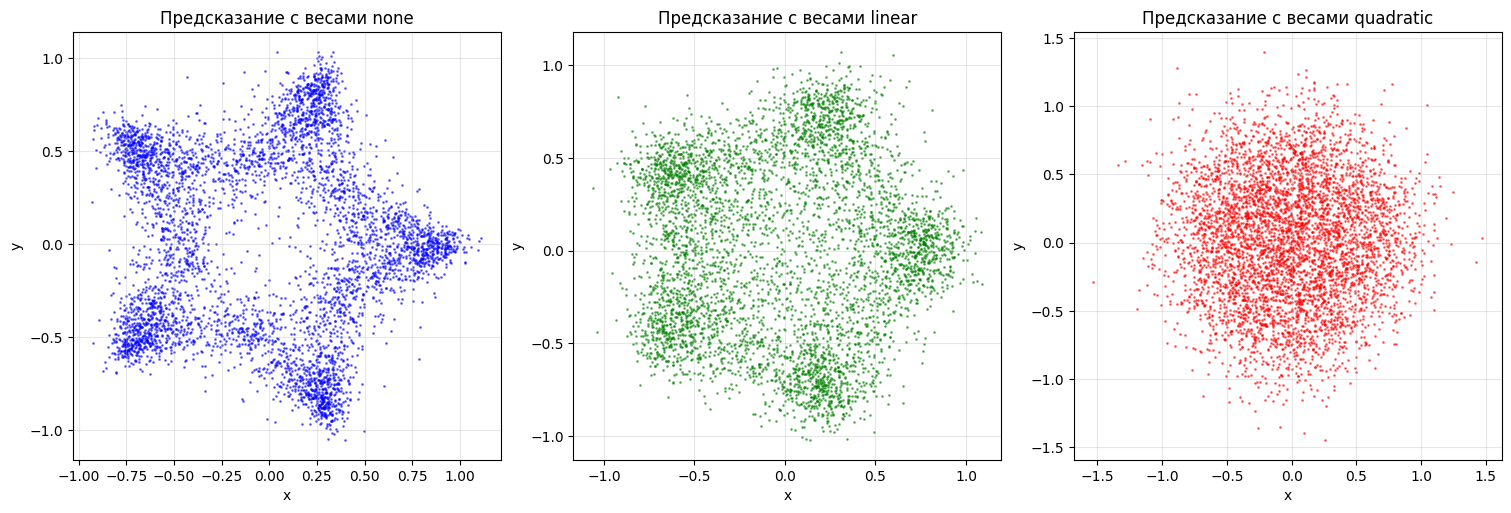

In [112]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

for i, method in enumerate(weighting_methods):
    ax = axes[i]
    samples = results[method]['samples']

    ax.scatter(samples[:, 0], samples[:, 1],
                  s=1, alpha=0.5, c=colors[i])
    ax.set_box_aspect(1)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    #ax.set_aspect('equal')
    ax.set_title(f'Предсказание с весами {method}')
    ax.grid(True, alpha=0.3)

#plt.tight_layout()
plt.show()

3. Сравнение линейного и косинусового расписаний

In [121]:
schedule_methods = ['linear', 'cosine'] #'snr']

results_sch = {}

reference_star = generate_star(n_samples=10000)

for schedule in schedule_methods:
  print(f" ----> Тренируем с {schedule} расписанием")

  t_config = VPConfig()
  t_config.schedule_type = schedule
  t_config.epochs = 2000

  t_trainer = VPTrainer(t_config)
  t_trainer.run()
  samples = VPsample(t_trainer.model, t_config, num_samples=5000)

  results_sch[schedule] = {
      'samples': samples,
      'loss_history': t_trainer.loss_history,
      'config': t_config
  }
  print('\n')


 ----> Тренируем с linear расписанием
    Epoch: 0, loss: 0.841856042766571
    Epoch: 100, loss: 0.1833406007528305
    Epoch: 200, loss: 0.17585492777824402
    Epoch: 300, loss: 0.1715760400056839
    Epoch: 400, loss: 0.16207572779655458
    Epoch: 500, loss: 0.16602345280647277
    Epoch: 600, loss: 0.15675473980903626
    Epoch: 700, loss: 0.16087767879962922
    Epoch: 800, loss: 0.1621331179380417
    Epoch: 900, loss: 0.1585821473121643
    Epoch: 1000, loss: 0.15528009893894196
    Epoch: 1100, loss: 0.1604732419729233
    Epoch: 1200, loss: 0.15728370296955108
    Epoch: 1300, loss: 0.1552204534292221
    Epoch: 1400, loss: 0.1569776390314102
    Epoch: 1500, loss: 0.14796841280460357
    Epoch: 1600, loss: 0.15469886925220488
    Epoch: 1700, loss: 0.1558096889257431
    Epoch: 1800, loss: 0.1521521009683609
    Epoch: 1900, loss: 0.14880711205005645


 ----> Тренируем с cosine расписанием
    Epoch: 0, loss: 0.9081025971412658
    Epoch: 100, loss: 0.3300041921138763
    E

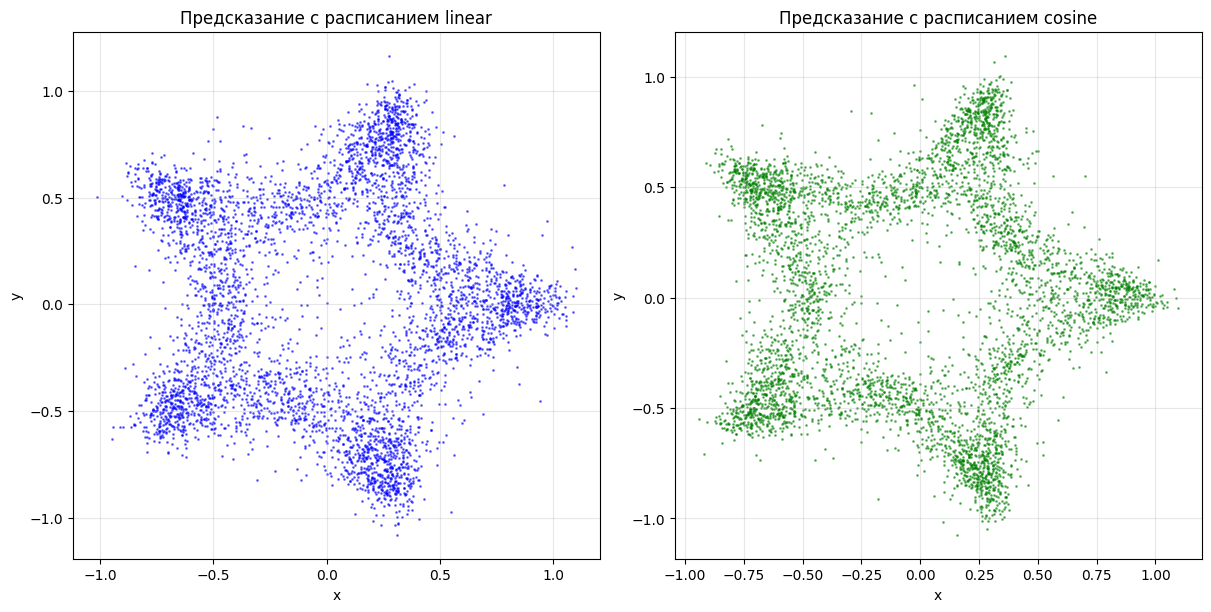

In [122]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

for i, schedule in enumerate(schedule_methods):
    ax = axes[i]
    samples = results_sch[schedule]['samples']

    ax.scatter(samples[:, 0], samples[:, 1],
                  s=1, alpha=0.5, c=colors[i])
    ax.set_box_aspect(1)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    #ax.set_aspect('equal')
    ax.set_title(f'Предсказание с расписанием {schedule}')
    ax.grid(True, alpha=0.3)

#plt.tight_layout()
plt.show()

**Вывод:**
  1. Отсутствие весов показло наилучший результат в сравнении с линейным и квадратичным распределениями, что объяснимо многомодальностью структуры и вынужденной обработкой всех возможных t (соответственно, лосс с none выше остальных лоссов)
  
  2. Оправдывая свою сложность в написании, косинусовое расписание на одних и тех же параметрах даёт лучший результат предсказания чем линейное расписание, что связано с быстрым падением SNR в линейном варианте (что приводит к затрудению в обучении).